In [24]:
import pandas as pd 
import matplotlib.pyplot as plt
df=pd.read_csv("messy.csv")
df.head()

,OrderID,Category,Region,Sales,Profit,Discount,Quantity
0,1,Technology,West,2500.0,300.0,0.10,5.0
1,2,Furniture,East,1800.0,200.0,0.20,3.0
2,3,Office Supplies,South,300.0,50.0,NaN,2.0
3,4,Technology,North,4000.0,500.0,0.15,6.0
4,5,Furniture,West,1200.0,-100.0,0.30,4.0


In [25]:
df.dtypes

OrderID       int64
Category     object
Region       object
Sales       float64
Profit      float64
Discount    float64
Quantity    float64
dtype: object

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   OrderID   30 non-null     int64  
 1   Category  30 non-null     object 
 2   Region    30 non-null     object 
 3   Sales     28 non-null     float64
 4   Profit    29 non-null     float64
 5   Discount  28 non-null     float64
 6   Quantity  29 non-null     float64
dtypes: float64(4), int64(1), object(2)
memory usage: 1.8+ KB


In [27]:
m=df["Sales"].mean()
df["Sales"]=df["Sales"].fillna(m)
df["Profit"].fillna(0,inplace=True)
df["Discount"].fillna(0,inplace=True)
df["Quantity"].fillna(0,inplace=True)
df

C:\Users\niveditha\AppData\Local\Temp\ipykernel_21256\4187940584.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Profit"].fillna(0,inplace=True)
C:\Users\niveditha\AppData\Local\Temp\ipykernel_21256\4187940584.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

,OrderID,Category,Region,Sales,Profit,Discount,Quantity
0,1,Technology,West,2500.000000,300.0,0.10,5.0
1,2,Furniture,East,1800.000000,200.0,0.20,3.0
2,3,Office Supplies,South,300.000000,50.0,0.00,2.0
3,4,Technology,North,4000.000000,500.0,0.15,6.0
4,5,Furniture,West,1200.000000,-100.0,0.30,4.0
5,6,Office Supplies,East,150.000000,20.0,0.05,1.0
6,7,Technology,South,3200.000000,400.0,0.10,5.0
7,8,Furniture,North,800.000000,-50.0,0.25,2.0
8,9,Office Supplies,West,200.000000,30.0,0.00,3.0
9,10,Technology,East,5000.000000,700.0,0.05,7.0


In [28]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          12400.000000
Office Supplies     3798.214286
Technology         39248.214286
Name: Sales, dtype: float64

In [29]:
df.groupby("Region")["Profit"].sum()

Region
East     1867.0
North    1545.0
South    1475.0
West      765.0
Name: Profit, dtype: float64

In [32]:
df[df["Discount"]>0.05]

,OrderID,Category,Region,Sales,Profit,Discount,Quantity
0,1,Technology,West,2500.000000,300.0,0.10,5.0
1,2,Furniture,East,1800.000000,200.0,0.20,3.0
3,4,Technology,North,4000.000000,500.0,0.15,6.0
4,5,Furniture,West,1200.000000,-100.0,0.30,4.0
6,7,Technology,South,3200.000000,400.0,0.10,5.0
7,8,Furniture,North,800.000000,-50.0,0.25,2.0
10,11,Furniture,South,1000.000000,150.0,0.10,3.0
12,13,Technology,West,2800.000000,350.0,0.10,4.0
13,14,Furniture,East,1600.000000,180.0,0.20,3.0
15,16,Technology,North,4200.000000,600.0,0.15,6.0


In [31]:
df[df["Profit"] < 0]

,OrderID,Category,Region,Sales,Profit,Discount,Quantity
4,5,Furniture,West,1200.0,-100.0,0.30,4.0
7,8,Furniture,North,800.0,-50.0,0.25,2.0
16,17,Furniture,West,1300.0,-80.0,0.30,4.0
19,20,Furniture,North,900.0,-60.0,0.25,2.0
24,25,Furniture,West,1250.0,-90.0,0.30,0.0
27,28,Furniture,North,850.0,-55.0,0.25,2.0


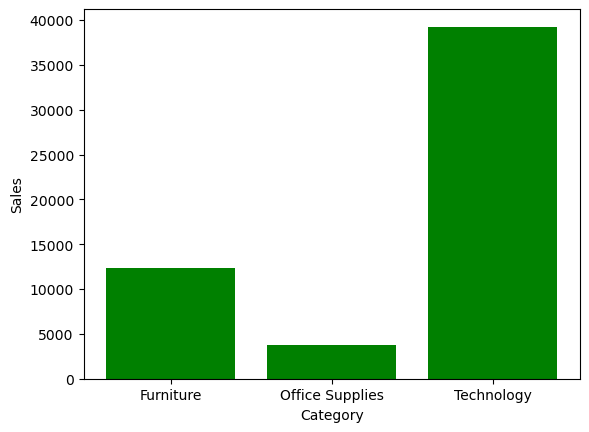

In [33]:
c_s=df.groupby("Category")["Sales"].sum()
plt.bar(c_s.index,c_s.values,color="green")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

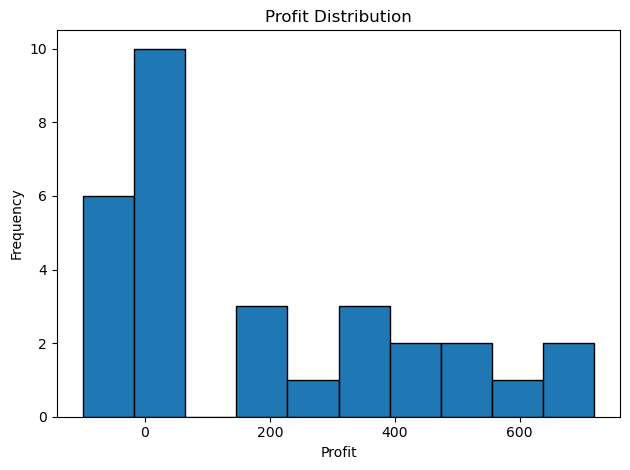

In [40]:
plt.hist(df["Profit"],bins=10,edgecolor="black")
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#1.The dataset contains sales data across Technology, Furniture, and Office Supplies categories in different regions.

#2.Technology products generate the highest sales

#3.Furniture category includes several negative profit values, indicating losses in some transactions.

#4.Most profit values are concentrated in the positive range, but a few negative values act as outliers.

#5.Missing values were present in multiple columns and were handled using mean to ensure consistency.